# Section 1: Imports and Setup
This section imports all required libraries, sets seeds for reproducibility, and configures the training device (GPU if available, otherwise CPU).

In [4]:
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

from tqdm.auto import tqdm

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


# Section 2: Dataset Loading and Exploration
This section loads the dataset directly from the existing train/ and val/ folders, applies train-only augmentation, builds data loaders, and prints class distributions.

In [5]:
data_root = r'C:\Users\nirjo\OneDrive\Desktop\dataset\dataset'
train_dir = os.path.join(data_root, 'train')
val_dir = os.path.join(data_root, 'val')

if not os.path.isdir(train_dir) or not os.path.isdir(val_dir):
    raise FileNotFoundError(
        f'Expected train/ and val/ folders under: {data_root}'
    )

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

class_name_map = {
    'no': 'no_substructure',
    'sphere': 'subhalo',
    'vort': 'vortex'
}

class NpyFolderDataset(Dataset):
    def __init__(self, root_dir, class_to_idx=None, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform

        if class_to_idx is None:
            class_names = sorted([p.name for p in self.root_dir.iterdir() if p.is_dir()])
            self.class_to_idx = {name: i for i, name in enumerate(class_names)}
        else:
            self.class_to_idx = class_to_idx

        self.classes = sorted(self.class_to_idx, key=self.class_to_idx.get)
        self.samples = []

        for class_name, class_idx in self.class_to_idx.items():
            class_dir = self.root_dir / class_name
            if not class_dir.is_dir():
                continue
            for npy_file in sorted(class_dir.glob('*.npy')):
                self.samples.append((str(npy_file), class_idx))

        if len(self.samples) == 0:
            raise FileNotFoundError(f'No .npy files found under {root_dir}')

        self.targets = [label for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        arr = np.load(file_path)

        # Convert normalized arrays to uint8 image for torchvision augmentations.
        arr = np.squeeze(arr)
        if arr.ndim != 2:
            raise ValueError(f'Expected 2D array, got shape {arr.shape} in {file_path}')

        arr = np.nan_to_num(arr, nan=0.0, posinf=1.0, neginf=0.0)
        arr = np.clip(arr, 0.0, 1.0)
        arr_uint8 = (arr * 255.0).astype(np.uint8)
        img = Image.fromarray(arr_uint8, mode='L')

        if self.transform is not None:
            img = self.transform(img)

        return img, label

train_dataset = NpyFolderDataset(root_dir=train_dir, transform=train_transform)
test_dataset = NpyFolderDataset(
    root_dir=val_dir,
    class_to_idx=train_dataset.class_to_idx,
    transform=val_transform
)

if train_dataset.class_to_idx != test_dataset.class_to_idx:
    raise ValueError('Train and val class mappings do not match.')

idx_to_class = train_dataset.classes
display_class_names = [class_name_map.get(c, c) for c in idx_to_class]

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Train folder: {train_dir}')
print(f'Validation folder: {val_dir}')
print(f'Train images: {len(train_dataset)}')
print(f'Validation images: {len(test_dataset)}')

train_labels = np.array(train_dataset.targets)
test_labels = np.array(test_dataset.targets)

print('\nClass mapping (folder -> display):')
for c in idx_to_class:
    print(f'  {c} -> {class_name_map.get(c, c)}')

print('\nClass distribution in train set:')
for i, name in enumerate(display_class_names):
    print(f'  {name}: {(train_labels == i).sum()}')

print('\nClass distribution in validation set:')
for i, name in enumerate(display_class_names):
    print(f'  {name}: {(test_labels == i).sum()}')

Train folder: C:\Users\nirjo\OneDrive\Desktop\dataset\dataset\train
Validation folder: C:\Users\nirjo\OneDrive\Desktop\dataset\dataset\val
Train images: 30000
Validation images: 7500

Class mapping (folder -> display):
  no -> no_substructure
  sphere -> subhalo
  vort -> vortex

Class distribution in train set:
  no_substructure: 10000
  subhalo: 10000
  vortex: 10000

Class distribution in validation set:
  no_substructure: 2500
  subhalo: 2500
  vortex: 2500


This cell visualizes sample training images after augmentation and normalization (displayed after inverse normalization).

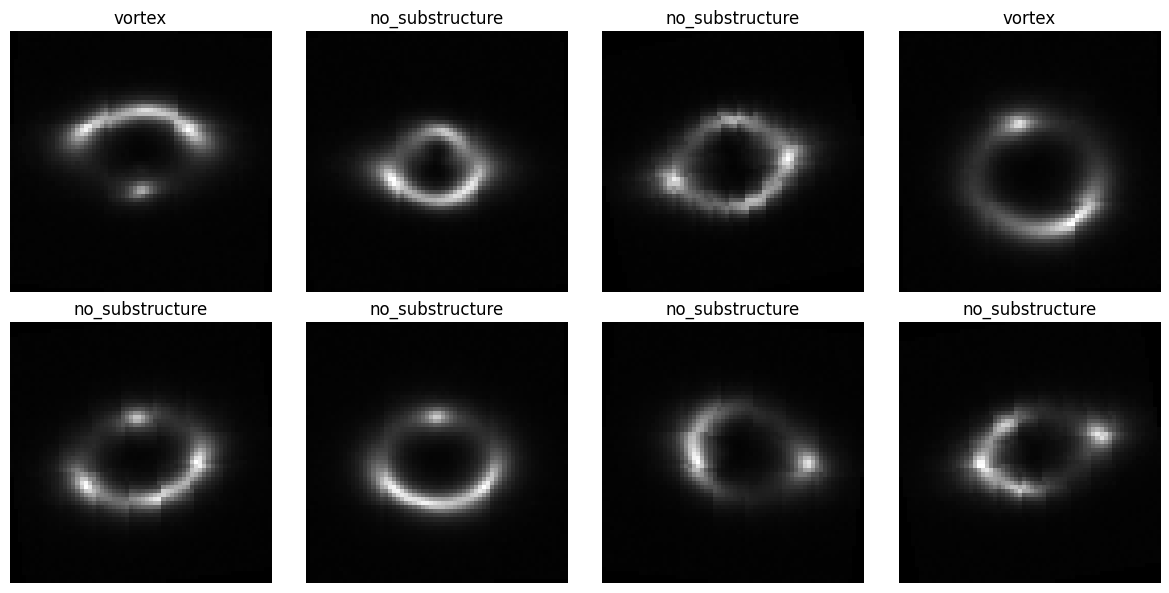

In [6]:
def denormalize(img_tensor):
    img = img_tensor * 0.5 + 0.5
    return img.clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.flatten():
    idx = random.randint(0, len(train_dataset) - 1)
    img, label = train_dataset[idx]
    img_show = denormalize(img).squeeze(0).numpy()
    ax.imshow(img_show, cmap='gray')
    ax.set_title(display_class_names[label])
    ax.axis('off')

plt.tight_layout()
plt.show()

# Section 3: Model Architecture
This section creates a pretrained ResNet18, adapts it for grayscale images by changing the first convolution layer, and changes the classifier to output 3 classes.

In [7]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

old_conv = model.conv1
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

with torch.no_grad():
    model.conv1.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))

model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 20

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\nirjo/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 22.5MB/s]


ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Section 4: Training Loop with Loss Tracking
This section trains the model for 20 epochs with a tqdm progress bar, and prints training loss and accuracy for every epoch.

Epoch [1/20] - Loss: 1.1576 - Accuracy: 0.3415


Epoch [2/20] - Loss: 1.0972 - Accuracy: 0.3639


Epoch [3/20] - Loss: 1.0837 - Accuracy: 0.3838


Epoch [4/20] - Loss: 1.0676 - Accuracy: 0.4067


Epoch [5/20] - Loss: 1.0432 - Accuracy: 0.4395


...

Epoch [16/20] - Loss: 0.7917 - Accuracy: 0.6313


Epoch [17/20] - Loss: 0.7746 - Accuracy: 0.6357


Epoch [18/20] - Loss: 0.7707 - Accuracy: 0.6412


Epoch [19/20] - Loss: 0.7497 - Accuracy: 0.6511


Epoch [20/20] - Loss: 0.7354 - Accuracy: 0.6601


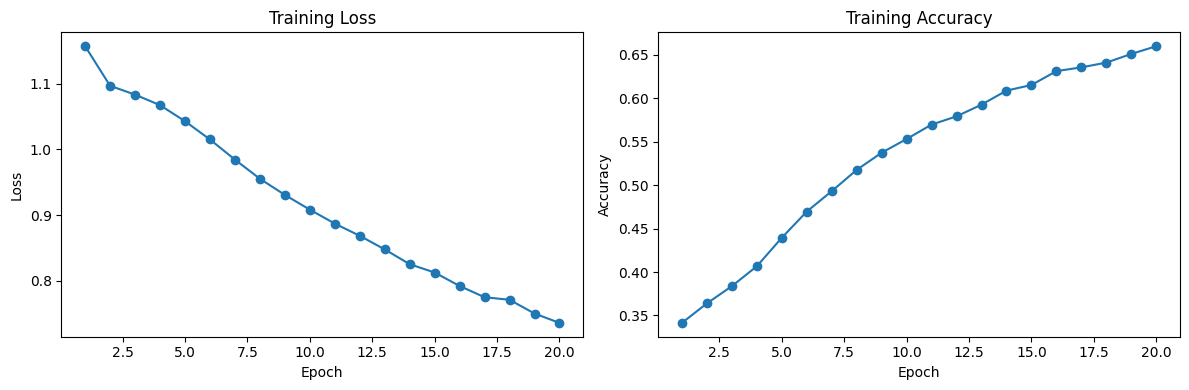

In [8]:
train_losses = []
train_accuracies = []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{num_epochs}', leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_size_curr = labels.size(0)
        running_loss += loss.item() * batch_size_curr
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_samples += batch_size_curr

        progress_bar.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f'Epoch [{epoch}/{num_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

# Section 5: Evaluation on Test Set
This section evaluates the trained model on the test set and shows a confusion matrix.

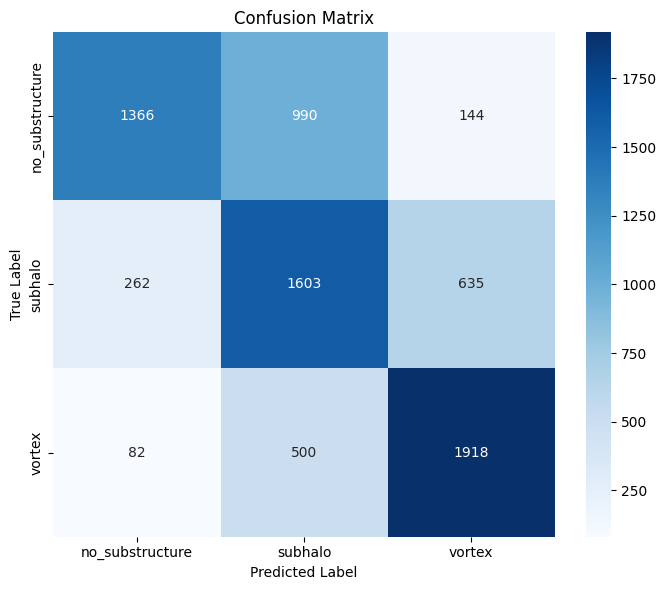

In [9]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=display_class_names, yticklabels=display_class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Section 6: ROC Curve and AUC Scores
This section computes one-vs-rest ROC curves for all 3 classes using label binarization, plots all curves on the same graph, saves the plot as roc_curve.png, and prints per-class and macro average AUC scores.

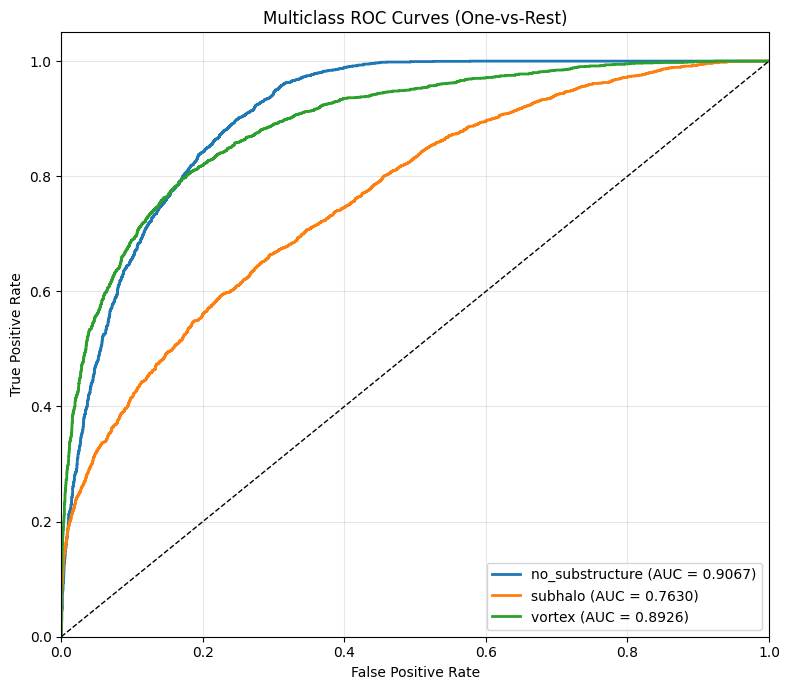

Final AUC scores:
  no_substructure: 0.9067
  subhalo: 0.7630
  vortex: 0.8926
Macro Average AUC: 0.8541


In [10]:
num_classes = 3
y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

macro_auc = float(np.mean([roc_auc[i] for i in range(num_classes)]))

plt.figure(figsize=(8, 7))
for i in range(num_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f'{display_class_names[i]} (AUC = {roc_auc[i]:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()

print('Final AUC scores:')
for i in range(num_classes):
    print(f'  {display_class_names[i]}: {roc_auc[i]:.4f}')
print(f'Macro Average AUC: {macro_auc:.4f}')

# Section 7: Save Model Weights
This section saves the trained model weights in PyTorch format as resnet18_lensing.pth.

In [13]:
model_path = 'resnet18_lensing.pth'
torch.save(model.state_dict(), model_path)
print(f'Model weights saved to: {os.path.abspath(model_path)}')
print(f'ROC plot saved to: {os.path.abspath("roc_curve.png")}')

Model weights saved to: c:\Users\nirjo\gsoc-2026-ml4sci\resnet18_lensing.pth
ROC plot saved to: c:\Users\nirjo\gsoc-2026-ml4sci\roc_curve.png
